E[Y]       = 1.2500   -> média cresce
exp E[lnY] = 1.0000   -> típica estável (martingale em log)
E[Y^2]     = 2.1250
CV final   : empírico 6.293e+01 | teórico 2.259e+13
% abaixo de c0 na última rodada: 47.6%


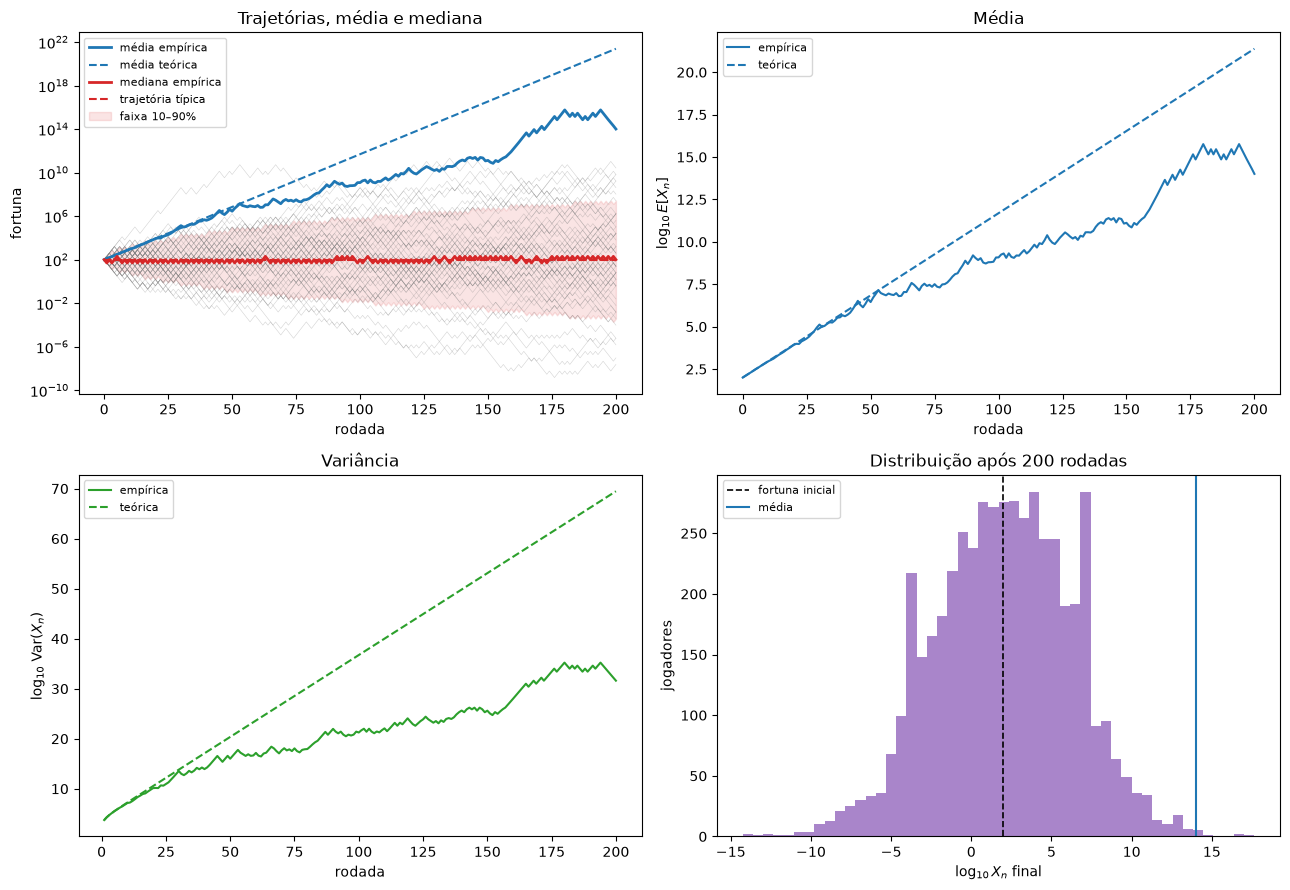

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- parâmetros ----------------
c0        = 100.0   # fortuna inicial (igual para todos)
p         = 0.5     # probabilidade de ganhar
mult_win  = 2.0     # multiplicador se ganha
mult_lose = 0.5     # multiplicador se perde
n_rodadas = 200
n_jogador = 5000
seed      = 42

rng = np.random.default_rng(seed)

# ---------------- simulação (em log, para não estourar) ----------------
ln_win, ln_lose = np.log(mult_win), np.log(mult_lose)

ganhos = rng.random((n_jogador, n_rodadas)) < p
passos = np.where(ganhos, ln_win, ln_lose)

L = np.empty((n_jogador, n_rodadas + 1))      # L[i,t] = log(fortuna)
L[:, 0] = np.log(c0)
L[:, 1:] = np.log(c0) + np.cumsum(passos, axis=1)

# ---------------- estatísticas estáveis ----------------
def log_mean_exp(L, k=1):
    """log( média_i exp(k*L_i) ) sem overflow."""
    m = (k * L).max(axis=0)
    return m + np.log(np.exp(k * L - m).mean(axis=0))

log_media = log_mean_exp(L, 1)                 # log E[X_n]
log_m2    = log_mean_exp(L, 2)                 # log E[X_n^2]

d = np.clip(2 * log_media - log_m2, None, 0.0)  # <= 0 por Jensen
with np.errstate(divide="ignore"):
    log_var = log_m2 + np.log1p(-np.exp(d))     # log Var(X_n)
log_var[~np.isfinite(log_var)] = np.nan         # Var(X_0)=0 -> matplotlib pula

mediana  = np.exp(np.median(L, axis=0))
p10, p90 = np.exp(np.percentile(L, [10, 90], axis=0))
frac_abaixo = (L < np.log(c0)).mean(axis=0)

# ---------------- teoria ----------------
n = np.arange(n_rodadas + 1)
EY   = p * mult_win + (1 - p) * mult_lose
EY2  = p * mult_win**2 + (1 - p) * mult_lose**2
ElnY = p * ln_win + (1 - p) * ln_lose

log_media_teo = np.log(c0) + n * np.log(EY)
r = EY**2 / EY2
with np.errstate(divide="ignore"):
    log_var_teo = 2*np.log(c0) + n*np.log(EY2) + np.log1p(-r**n)
log_var_teo[~np.isfinite(log_var_teo)] = np.nan
tipica_teo = c0 * np.exp(n * ElnY)             # trajetória típica (mediana)

tol = 1e-12
est_media = "cresce" if EY > 1 + tol else ("decresce" if EY < 1 - tol else "estável")
est_tip   = "cresce" if ElnY > tol else ("decresce" if ElnY < -tol else "estável (martingale em log)")

cv_emp = np.exp(0.5*log_var[-1] - log_media[-1])
cv_teo = np.sqrt(np.expm1(n_rodadas * np.log(EY2 / EY**2)))

print(f"E[Y]       = {EY:.4f}   -> média {est_media}")
print(f"exp E[lnY] = {np.exp(ElnY):.4f}   -> típica {est_tip}")
print(f"E[Y^2]     = {EY2:.4f}")
print(f"CV final   : empírico {cv_emp:.3e} | teórico {cv_teo:.3e}")
print(f"% abaixo de c0 na última rodada: {100*frac_abaixo[-1]:.1f}%")

# ---------------- gráficos ----------------
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

a = ax[0, 0]
for i in range(min(60, n_jogador)):
    a.plot(n, np.exp(L[i]), color="gray", lw=0.4, alpha=0.35)
a.plot(n, np.exp(log_media), "C0", lw=2, label="média empírica")
a.plot(n, np.exp(log_media_teo), "C0--", lw=1.5, label="média teórica")
a.plot(n, mediana, "C3", lw=2, label="mediana empírica")
a.plot(n, tipica_teo, "C3--", lw=1.5, label="trajetória típica")
a.fill_between(n, p10, p90, color="C3", alpha=0.12, label="faixa 10–90%")
a.set_yscale("log"); a.set_xlabel("rodada"); a.set_ylabel("fortuna")
a.set_title("Trajetórias, média e mediana"); a.legend(fontsize=8)

a = ax[0, 1]
a.plot(n, log_media / np.log(10), "C0", label="empírica")
a.plot(n, log_media_teo / np.log(10), "C0--", label="teórica")
a.set_xlabel("rodada"); a.set_ylabel(r"$\log_{10} E[X_n]$")
a.set_title("Média"); a.legend(fontsize=8)

a = ax[1, 0]
a.plot(n, log_var / np.log(10), "C2", label="empírica")
a.plot(n, log_var_teo / np.log(10), "C2--", label="teórica")
a.set_xlabel("rodada"); a.set_ylabel(r"$\log_{10}\,\mathrm{Var}(X_n)$")
a.set_title("Variância"); a.legend(fontsize=8)

a = ax[1, 1]
a.hist(L[:, -1] / np.log(10), bins=50, color="C4", alpha=0.8)
a.axvline(np.log10(c0), color="k", ls="--", lw=1.2, label="fortuna inicial")
a.axvline(log_media[-1] / np.log(10), color="C0", lw=1.5, label="média")
a.set_xlabel(r"$\log_{10} X_n$ final"); a.set_ylabel("jogadores")
a.set_title(f"Distribuição após {n_rodadas} rodadas"); a.legend(fontsize=8)

plt.tight_layout()
plt.show()

E[Y] = 1.25,  E[Y^2] = 2.125

  n      média sim      média teo      mediana
  0          100.0          100.0        100.0
  5          307.5          305.2        200.0
 10          934.9          931.3        100.0
 20         8770.9         8673.6        100.0
 30       163069.6        80779.4        100.0


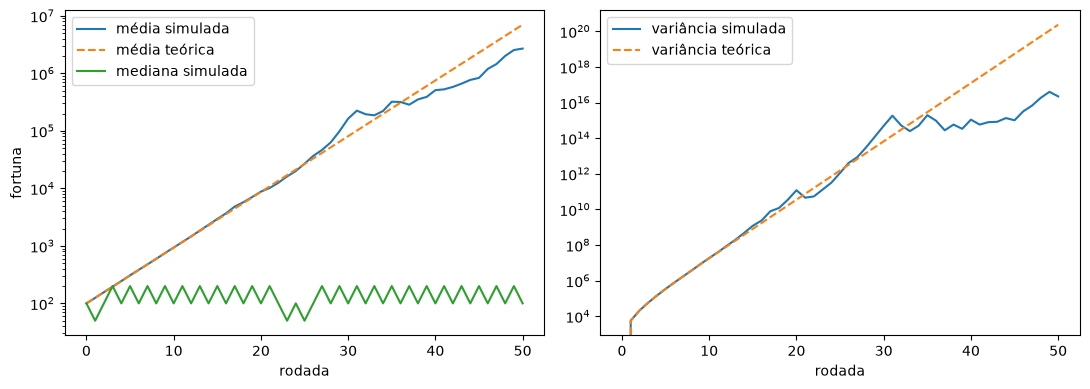

In [6]:
import numpy as np
import matplotlib.pyplot as plt

c0        = 100.0
p         = 0.5
mult_win  = 2.0
mult_lose = 0.5
n_rodadas = 50
n_jogador = 100000

rng = np.random.default_rng(42)

# fortuna[i, t] = dinheiro do jogador i na rodada t
fortuna = np.empty((n_jogador, n_rodadas + 1))
fortuna[:, 0] = c0

for t in range(1, n_rodadas + 1):
    ganhou = rng.random(n_jogador) < p
    fator = np.where(ganhou, mult_win, mult_lose)
    fortuna[:, t] = fortuna[:, t-1] * fator

media = fortuna.mean(axis=0)
variancia = fortuna.var(axis=0)
mediana = np.median(fortuna, axis=0)

# teoria
n = np.arange(n_rodadas + 1)
EY  = p * mult_win + (1 - p) * mult_lose          # 5/4
EY2 = p * mult_win**2 + (1 - p) * mult_lose**2    # 17/8
media_teo = c0 * EY**n
var_teo = c0**2 * (EY2**n - EY**(2*n))

print(f"E[Y] = {EY},  E[Y^2] = {EY2}\n")
print(f"{'n':>3} {'média sim':>14} {'média teo':>14} {'mediana':>12}")
for t in [0, 5, 10, 20, 30]:
    print(f"{t:>3} {media[t]:>14.1f} {media_teo[t]:>14.1f} {mediana[t]:>12.1f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(n, media, label="média simulada")
ax[0].plot(n, media_teo, "--", label="média teórica")
ax[0].plot(n, mediana, label="mediana simulada")
ax[0].set_yscale("log"); ax[0].set_xlabel("rodada"); ax[0].set_ylabel("fortuna")
ax[0].legend()

ax[1].plot(n, variancia, label="variância simulada")
ax[1].plot(n, var_teo, "--", label="variância teórica")
ax[1].set_yscale("log"); ax[1].set_xlabel("rodada")
ax[1].legend()

plt.tight_layout()
plt.show()

jogador #32178
fortuna final: 26,843,545,600.00
vitórias: 39 de 50


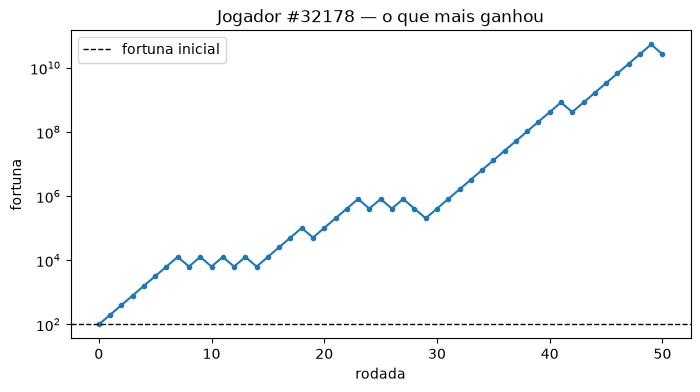

In [7]:
i_max = fortuna[:, -1].argmax()          # índice do jogador mais sortudo
trajetoria = fortuna[i_max]              # a linha inteira dele

vitorias = (n_rodadas + np.log2(trajetoria[-1] / c0)) / 2

print(f"jogador #{i_max}")
print(f"fortuna final: {trajetoria[-1]:,.2f}")
print(f"vitórias: {vitorias:.0f} de {n_rodadas}")

plt.figure(figsize=(8, 4))
plt.plot(n, trajetoria, marker="o", ms=3)
plt.axhline(c0, color="k", ls="--", lw=1, label="fortuna inicial")
plt.yscale("log")
plt.xlabel("rodada"); plt.ylabel("fortuna")
plt.title(f"Jogador #{i_max} — o que mais ganhou")
plt.legend()
plt.show()

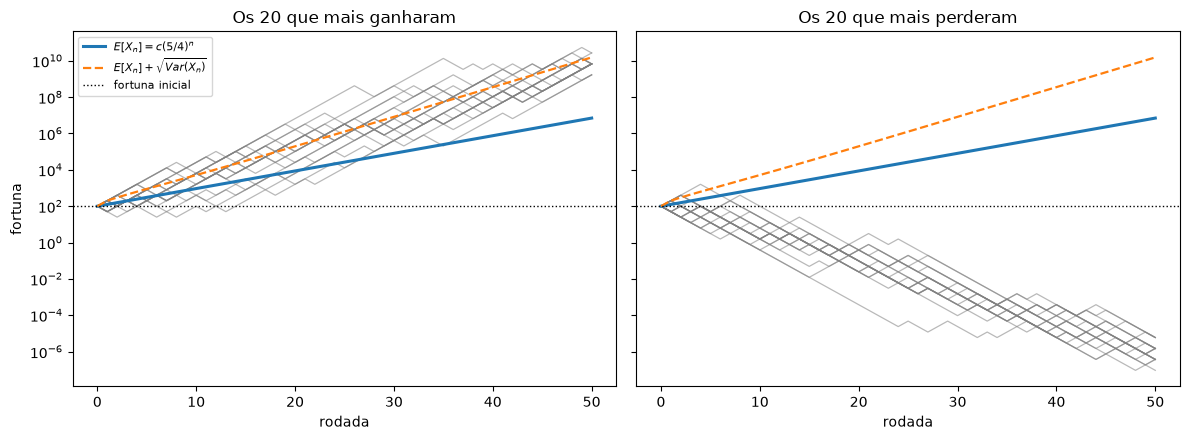

  n         E[X_n]    desvio padrão           E - dp
  0          100.0              0.0            100.0
 10          931.3           4231.8          -3300.5
 20         8673.6         187553.6        -178880.0
 30        80779.4        8135094.6       -8054315.2


In [13]:
X = 20

ordem = fortuna[:, -1].argsort()
piores, melhores = ordem[:X], ordem[-X:]

# teoria
EY  = p * mult_win + (1 - p) * mult_lose
EY2 = p * mult_win**2 + (1 - p) * mult_lose**2
media_teo = c0 * EY**n
var_teo   = c0**2 * (EY2**n - EY**(2*n))
dp_teo    = np.sqrt(var_teo)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for i in melhores:
    ax[0].plot(n, fortuna[i], lw=0.9, alpha=0.55, color="gray")
ax[0].set_title(f"Os {X} que mais ganharam")

for i in piores:
    ax[1].plot(n, fortuna[i], lw=0.9, alpha=0.55, color="gray")
ax[1].set_title(f"Os {X} que mais perderam")

for a in ax:
    a.plot(n, media_teo, "C0", lw=2.2, label=r"$E[X_n] = c(5/4)^n$")
    a.plot(n, media_teo + dp_teo, "C1--", lw=1.6, label=r"$E[X_n] + \sqrt{Var(X_n)}$")
    a.axhline(c0, color="k", ls=":", lw=1, label="fortuna inicial")
    a.set_yscale("log")
    a.set_xlabel("rodada")
ax[0].set_ylabel("fortuna")
ax[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"{'n':>3} {'E[X_n]':>14} {'desvio padrão':>16} {'E - dp':>16}")
for t in [0, 10, 20, 30]:
    print(f"{t:>3} {media_teo[t]:>14.1f} {dp_teo[t]:>16.1f} {media_teo[t]-dp_teo[t]:>16.1f}")